In [1]:
## test1
from bigrams import BIGRAM_BAG

print(len(BIGRAM_BAG))
print(BIGRAM_BAG[:5])

40
['th', 'he', 'in', 'er', 'an']


In [2]:
## test2
from text_processing import count_tracked_bigrams, counts_to_vector

sentence = "The queen quickly quit the quiet quiz"
counts = count_tracked_bigrams(sentence)
print(counts)

vector = counts_to_vector(counts)
print(vector)

Counter({'th': 2, 'he': 2, 'en': 1, 'ic': 1, 'it': 1})
[2. 2. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


In [3]:
## test 3
from typing_env import TypingEnv

env = TypingEnv()
env.reset()

for _ in range(5):
    state, reward, _, _ = env.step(0)
    print("Reward:", reward)

Avg skill before: 0.24823115021288727
Avg skill after : 0.2579191554375583
Reward: 0.04968800522467101
Avg skill before: 0.2579191554375583
Avg skill after : 0.27504399011227637
Reward: 0.09712483467471811
Avg skill before: 0.27504399011227637
Avg skill after : 0.2838948954141055
Reward: 0.08885090530182915
Avg skill before: 0.2838948954141055
Avg skill after : 0.29039240092516644
Reward: 0.10649750551106094
Avg skill before: 0.29039240092516644
Avg skill after : 0.29356514025709435
Reward: 0.06317273933192791


In [4]:
## test 4
env.sample_sentence(0,1)

'the health of the earth matters to those who think'

### we can see the skill growing, as we ran 5 iterations, and rewards are positive.

In [5]:
## test 5
env = TypingEnv()
state = env.reset()

for _ in range(5):
    action = 0  # same bigram
    state, reward, _, _ = env.step(action)
    print("Reward:", reward)
    print("Skill:", env.k[0])

Avg skill before: 0.2499088883950722
Avg skill after : 0.259843535396547
Reward: 0.06993464700147478
Skill: 0.38754796261671987
Avg skill before: 0.259843535396547
Avg skill after : 0.267355941031591
Reward: 0.06751240563504401
Skill: 0.4863109689853755
Avg skill before: 0.267355941031591
Avg skill after : 0.2861342913769181
Reward: 0.09377835034532711
Skill: 0.5793204116784787
Avg skill before: 0.2861342913769181
Avg skill after : 0.2930525352192254
Reward: 0.04025157717564066
Skill: 0.6202506456992417
Avg skill before: 0.2930525352192254
Avg skill after : 0.3041147129197911
Reward: 0.09106217770056568
Skill: 0.7019009858794365


### Forgetting Curve

Avg skill before: 0.2478958382140064
Avg skill after : 0.27245354925725856
Avg skill before: 0.27245354925725856
Avg skill after : 0.30302489119549775
Avg skill before: 0.30302489119549775
Avg skill after : 0.3203999526285304
Avg skill before: 0.3203999526285304
Avg skill after : 0.34314750569139474
Avg skill before: 0.34314750569139474
Avg skill after : 0.3590221458132457
Avg skill before: 0.3590221458132457
Avg skill after : 0.38413496139370706
Avg skill before: 0.38413496139370706
Avg skill after : 0.40826110356610557
Avg skill before: 0.40826110356610557
Avg skill after : 0.4270001806722867
Avg skill before: 0.4270001806722867
Avg skill after : 0.4497497869643651
Avg skill before: 0.4497497869643651
Avg skill after : 0.4708297202607691
Avg skill before: 0.4708297202607691
Avg skill after : 0.4832180011941807
Avg skill before: 0.4832180011941807
Avg skill after : 0.4996403158255916
Avg skill before: 0.4996403158255916
Avg skill after : 0.51909380622047
Avg skill before: 0.5190938062

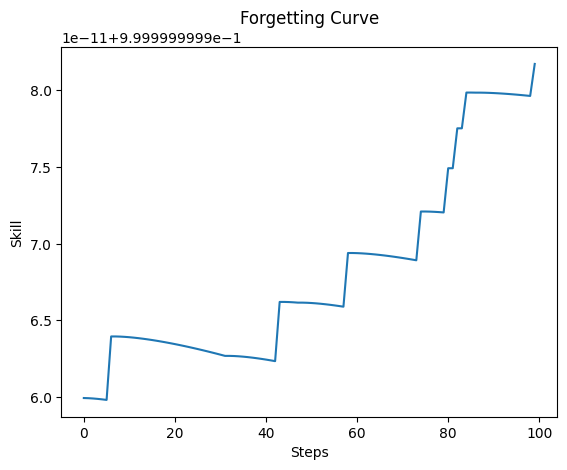

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from typing_env import TypingEnv


env = TypingEnv()
state = env.reset()

target_bigram = 39
difficulty = 3
action = target_bigram * env.L + difficulty

# forgetting curve experiment
env.reset()

learning_steps = 100
forget_steps = 100

forget_curve = []

# learn first
for step in range(learning_steps):
    state, reward, done, _ = env.step(action)

# stop practicing target bigram
for step in range(forget_steps):
    random_action = np.random.randint(0, env.K * env.L)
    state, reward, done, _ = env.step(31)
    forget_curve.append(env.k[target_bigram])

print(forget_curve)

plt.plot(forget_curve)
plt.title("Forgetting Curve")
plt.xlabel("Steps")
plt.ylabel("Skill")

plt.show()

In [7]:
import pandas as pd
df = pd.read_csv("typing_dataset.csv")
df.head()


,sentence,target_bigram,difficulty
0,the thin cat sat on the mat,th,0
1,this path has the moth on it,th,0
2,that cloth has both the moths,th,0
3,the bath with the thick cloth,th,0
4,both the teeth and the cloth,th,0


In [8]:

for i in range(20):
    j = i // 20
    if(i==0):
        print(f"for bigram {BIGRAM_BAG[j]}")
    sentence = df['sentence'][i]
    print(count_tracked_bigrams(sentence)[BIGRAM_BAG[j]])
    

for bigram th
3
4
5
6
5
5
5
5
5
5
5
5
5
6
5
5
5
5
5
5


In [9]:
import numpy as np
import matplotlib.pyplot as plt

from typing_env import TypingEnv

In [10]:
def run_random_agent(episodes=30, steps_per_episode=100):
    
    env = TypingEnv()
    
    K = env.K
    L = env.L
    
    all_rewards = []
    all_skills = []
    
    for ep in range(episodes):
        
        env.reset()
        
        episode_rewards = []
        episode_skills = []
        
        for step in range(steps_per_episode):
            
            action = np.random.randint(0, K * L)
            
            _, reward, _, _ = env.step(action)
            
            episode_rewards.append(reward)
            episode_skills.append(np.mean(env.k))
        
        all_rewards.append(np.mean(episode_rewards))
        all_skills.append(episode_skills[-1])  # final skill
        
    return all_rewards, all_skills

In [11]:
def select_action(env):
    
    scores = env.k - 0.1 * env.t
    weakest_bigram = np.argmin(scores)
    
    skill = env.k[weakest_bigram]
    
    if skill < 0.3:
        difficulty = 0
    elif skill < 0.5:
        difficulty = 1
    elif skill < 0.7:
        difficulty = 2
    elif skill < 0.85:
        difficulty = 3
    else:
        difficulty = 4
    
    return weakest_bigram * env.L + difficulty

In [12]:
def run_rule_agent(episodes=30, steps_per_episode=100):
    
    env = TypingEnv()
    
    all_rewards = []
    all_skills = []
    
    for ep in range(episodes):
        
        env.reset()
        
        episode_rewards = []
        episode_skills = []
        
        for step in range(steps_per_episode):
            
            action = select_action(env)
            
            _, reward, _, _ = env.step(action)
            
            episode_rewards.append(reward)
            episode_skills.append(np.mean(env.k))
        
        all_rewards.append(np.mean(episode_rewards))
        all_skills.append(episode_skills[-1])
        
    return all_rewards, all_skills

In [13]:
random_rewards, random_skills = run_random_agent()
rule_rewards, rule_skills = run_rule_agent()

Avg skill before: 0.24566604425468289
Avg skill after : 0.26115735871098844
Avg skill before: 0.26115735871098844
Avg skill after : 0.28827759894805743
Avg skill before: 0.28827759894805743
Avg skill after : 0.31618774214275386
Avg skill before: 0.31618774214275386
Avg skill after : 0.33568438614838136
Avg skill before: 0.33568438614838136
Avg skill after : 0.3714514308058363
Avg skill before: 0.3714514308058363
Avg skill after : 0.3792040206920689
Avg skill before: 0.3792040206920689
Avg skill after : 0.39880050097841907
Avg skill before: 0.39880050097841907
Avg skill after : 0.4062940088471675
Avg skill before: 0.4062940088471675
Avg skill after : 0.4239237207056621
Avg skill before: 0.4239237207056621
Avg skill after : 0.4303614056410793
Avg skill before: 0.4303614056410793
Avg skill after : 0.4539541975674867
Avg skill before: 0.4539541975674867
Avg skill after : 0.4735143600918602
Avg skill before: 0.4735143600918602
Avg skill after : 0.49871877467830467
Avg skill before: 0.498718

In [14]:
print("Random avg skill:", np.mean(random_skills))
print("Rule avg skill:", np.mean(rule_skills))

print("Random avg reward:", np.mean(random_rewards))
print("Rule avg reward:", np.mean(rule_rewards))

Random avg skill: 0.9283479426935511
Rule avg skill: 0.9446418412395213
Random avg reward: 0.06643126986169107
Rule avg reward: 0.06351113997213054


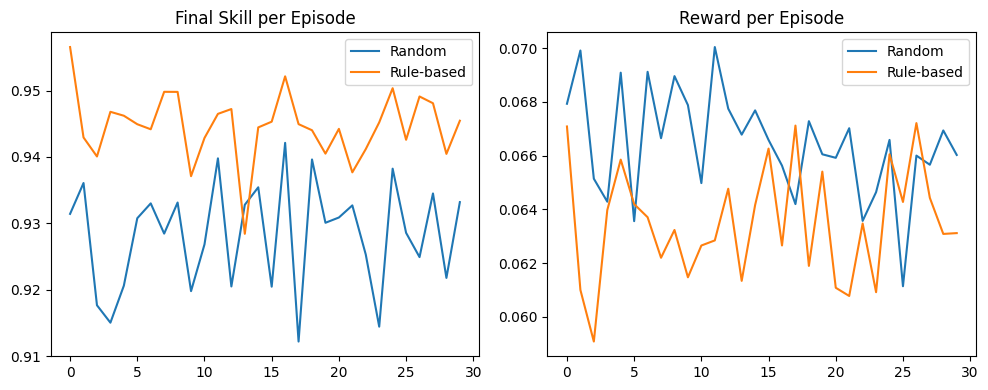

In [15]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(random_skills, label="Random")
plt.plot(rule_skills, label="Rule-based")
plt.title("Final Skill per Episode")
plt.legend()

plt.subplot(1,2,2)
plt.plot(random_rewards, label="Random")
plt.plot(rule_rewards, label="Rule-based")
plt.title("Reward per Episode")
plt.legend()

plt.tight_layout()
plt.show()